# Het Rank - 202301081

## Deep Learning Lab - 3: Convolutional Neural Networks


# Task 1 – Data Preparation

In [2]:
import torch
torch.cuda.is_available()

True

In [3]:
!pip install torch torchvision pandas scikit-learn matplotlib seaborn pillow

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("/content/drive/MyDrive/DL_Assignment_3/data.csv")

df = df[['Filename','AQI_Class']]

df.head()

,Filename,AQI_Class
0,BENGR_Good_2023-03-25-08.30-1-43.jpg,a_Good
1,BENGR_Good_2023-02-28-08.30-1-11.jpg,a_Good
2,BENGR_Good_2023-02-28-08.30-1-551.jpg,a_Good
3,TN_Good_2023-02-27-16.30-1-196.jpg,a_Good
4,BENGR_Good_2023-02-27-08.30-1-276.jpg,a_Good


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['AQI_Class'])

num_classes = df['label'].nunique()

print("Classes:", le.classes_)

Classes: ['a_Good' 'b_Moderate' 'c_Unhealthy_for_Sensitive_Groups' 'd_Unhealthy'
 'e_Very_Unhealthy' 'f_Severe']


In [8]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)

val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(len(train_df), len(val_df), len(test_df))

4200 900 900


In [9]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [10]:
class AQIDataset(Dataset):

    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_path = os.path.join(self.img_dir,
                                self.df.iloc[idx]['Filename'])

        image = Image.open(img_path).convert("RGB")

        label = self.df.iloc[idx]['label']

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
train_dataset = AQIDataset(train_df, "/content/drive/MyDrive/DL_Assignment_3/sampled_images", transform)
val_dataset = AQIDataset(val_df, "/content/drive/MyDrive/DL_Assignment_3/sampled_images", transform)
test_dataset = AQIDataset(test_df, "/content/drive/MyDrive/DL_Assignment_3/sampled_images", transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

# Task 2 — Basic CNN Model

In [12]:
class BasicCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28,512),
            nn.ReLU(),
            nn.Linear(512,num_classes)
        )

    def forward(self,x):

        x = self.conv(x)
        x = self.fc(x)

        return x

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_basic = BasicCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_basic.parameters(), lr=0.001)

In [14]:
epochs = 5

basic_train_losses = []
basic_val_losses = []

basic_train_acc = []
basic_val_acc = []

for epoch in range(epochs):

    model_basic.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model_basic(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs,1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_loss = running_loss/len(train_loader)
    train_accuracy = correct/total

    basic_train_losses.append(train_loss)
    basic_train_acc.append(train_accuracy)

    print("Epoch:", epoch+1, "Loss:", running_loss)

Epoch: 1 Loss: 179.14953756332397
Epoch: 2 Loss: 93.57397428154945
Epoch: 3 Loss: 50.48873224854469
Epoch: 4 Loss: 30.802173852920532
Epoch: 5 Loss: 24.12736754398793


In [15]:
#validation

model_basic.eval()

running_loss = 0
correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_basic(images)

        loss = criterion(outputs, labels)

        running_loss += loss.item()

        _, preds = torch.max(outputs,1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

val_loss = running_loss/len(val_loader)
val_accuracy = correct/total

basic_val_losses.append(val_loss)
basic_val_acc.append(val_accuracy)

print(f"Epoch {epoch+1}")
print(f"Train Loss {train_loss:.4f} | Train Acc {train_accuracy:.4f}")
print(f"Val Loss {val_loss:.4f} | Val Acc {val_accuracy:.4f}")

Epoch 5
Train Loss 0.1828 | Train Acc 0.9398
Val Loss 0.4709 | Val Acc 0.8444


# Task 3 — Transfer Learning (ResNet)

In [16]:
from torchvision import models

model_res = models.resnet18(pretrained=True)

for param in model_res.parameters():
    param.requires_grad = False

for param in model_res.layer4.parameters():
    param.requires_grad = True

model_res.fc = nn.Linear(model_res.fc.in_features, num_classes)

model_res = model_res.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_res.parameters(), lr=0.0001)

In [18]:
epochs = 5

res_train_losses = []
res_val_losses = []

res_train_acc = []
res_val_acc = []

for epoch in range(epochs):

    model_res.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model_res(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs,1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_loss = running_loss/len(train_loader)
    train_accuracy = correct/total

    res_train_losses.append(train_loss)
    res_train_acc.append(train_accuracy)

    print("Epoch:", epoch+1, "Loss:", running_loss)

Epoch: 1 Loss: 86.39142517745495
Epoch: 2 Loss: 15.461671559140086
Epoch: 3 Loss: 5.277137840166688
Epoch: 4 Loss: 3.163170533720404
Epoch: 5 Loss: 2.2413837492931634


In [19]:
#validation

model_res.eval()

running_loss = 0
correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_res(images)

        loss = criterion(outputs, labels)

        running_loss += loss.item()

        _, preds = torch.max(outputs,1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

val_loss = running_loss/len(val_loader)
val_accuracy = correct/total

res_val_losses.append(val_loss)
res_val_acc.append(val_accuracy)

print(f"Epoch {epoch+1}")
print(f"Train Loss {train_loss:.4f} | Train Acc {train_accuracy:.4f}")
print(f"Val Loss {val_loss:.4f} | Val Acc {val_accuracy:.4f}")

Epoch 5
Train Loss 0.0170 | Train Acc 0.9971
Val Loss 0.0812 | Val Acc 0.9789


# Task 4 — Evaluation (ResNet)

In [20]:
model_basic.eval()

y_true_basic = []
y_pred_basic = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model_basic(images)

        _, preds = torch.max(outputs,1)

        y_true_basic.extend(labels.numpy())
        y_pred_basic.extend(preds.cpu().numpy())

In [21]:
print("Basic CNN Results")

print(classification_report(
    y_true_basic,
    y_pred_basic,
    target_names=le.classes_
))

Basic CNN Results
                                  precision    recall  f1-score   support

                          a_Good       0.80      0.85      0.83       159
                      b_Moderate       0.85      0.87      0.86       163
c_Unhealthy_for_Sensitive_Groups       0.73      0.75      0.74       138
                     d_Unhealthy       0.90      0.81      0.85       151
                e_Very_Unhealthy       0.92      0.83      0.88       143
                        f_Severe       0.90      0.98      0.94       146

                        accuracy                           0.85       900
                       macro avg       0.85      0.85      0.85       900
                    weighted avg       0.85      0.85      0.85       900



In [22]:
model_res.eval()

y_true_res = []
y_pred_res = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model_res(images)

        _, preds = torch.max(outputs,1)

        y_true_res.extend(labels.numpy())
        y_pred_res.extend(preds.cpu().numpy())

In [23]:
print("ResNet Results")

print(classification_report(
    y_true_res,
    y_pred_res,
    target_names=le.classes_
))

ResNet Results
                                  precision    recall  f1-score   support

                          a_Good       0.99      0.97      0.98       159
                      b_Moderate       0.95      0.99      0.97       163
c_Unhealthy_for_Sensitive_Groups       0.99      0.94      0.97       138
                     d_Unhealthy       0.97      0.99      0.98       151
                e_Very_Unhealthy       1.00      0.98      0.99       143
                        f_Severe       0.98      1.00      0.99       146

                        accuracy                           0.98       900
                       macro avg       0.98      0.98      0.98       900
                    weighted avg       0.98      0.98      0.98       900



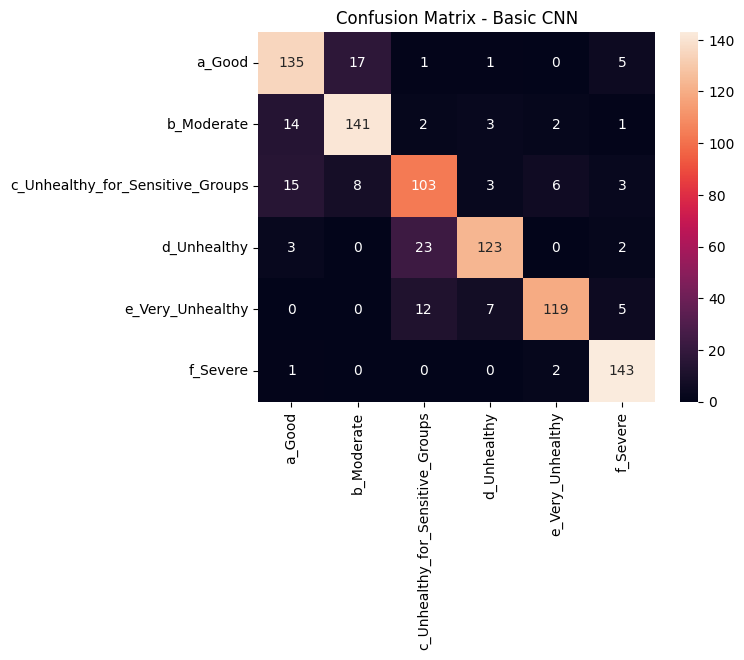

In [24]:
cm_basic = confusion_matrix(y_true_basic,y_pred_basic)

sns.heatmap(cm_basic,annot=True,fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("Confusion Matrix - Basic CNN")
plt.show()

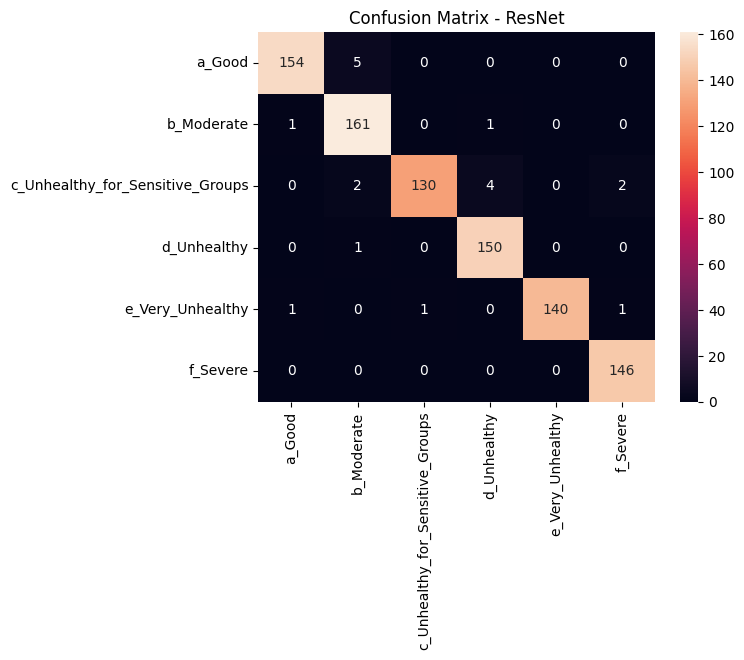

In [25]:
cm_res = confusion_matrix(y_true_res,y_pred_res)

sns.heatmap(cm_res,annot=True,fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("Confusion Matrix - ResNet")
plt.show()

# Task 5 — Training Curve

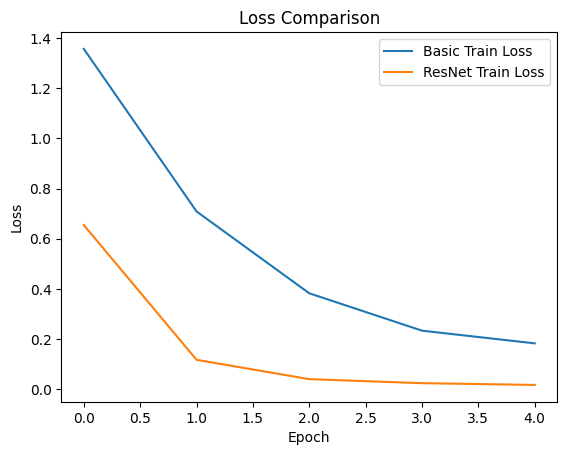

In [28]:
plt.figure()

plt.plot(basic_train_losses,label="Basic Train Loss")

plt.plot(res_train_losses,label="ResNet Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.title("Loss Comparison")

plt.show()

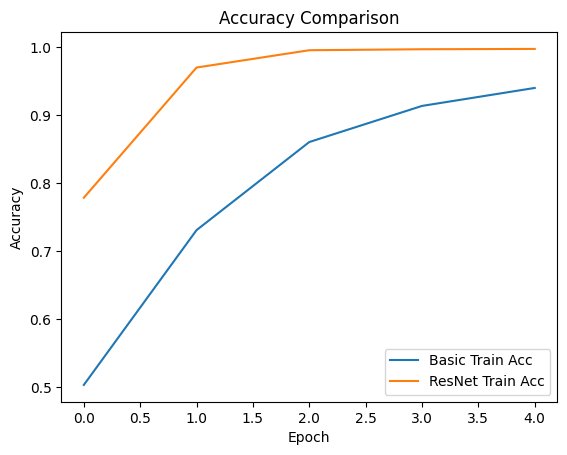

In [29]:
plt.figure()

plt.plot(basic_train_acc,label="Basic Train Acc")

plt.plot(res_train_acc,label="ResNet Train Acc")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.title("Accuracy Comparison")

plt.show()

## Why Pretrained Models Often Perform Better

Pretrained models are trained on large datasets such as ImageNet, which contains millions of images across many categories. During this training process, the model learns important visual features such as edges, textures, shapes, and patterns.

These learned features are general enough to be useful for many other computer vision tasks. When applying transfer learning, we reuse these learned representations and only adjust the final layers for the new classification task.

As a result, pretrained models usually achieve higher accuracy and faster convergence compared to models trained from scratch.

In this dataset, the pretrained ResNet model achieved better performance compared to the basic CNN trained from scratch. The pretrained model required fewer epochs to converge and produced higher classification accuracy.

This improvement occurs because the pretrained network already learned meaningful visual representations, which can be adapted to classify AQI images more effectively.

# Task 6 — Misclassification Analysis

In [31]:
misclassified = []

for i in range(len(y_true_res)):
    if y_true_res[i] != y_pred_res[i]:
        misclassified.append(i)

misclassified[:10]

[7, 113, 115, 134, 155, 206, 239, 254, 277, 301]

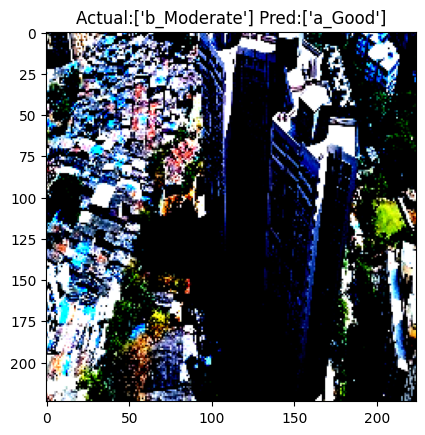

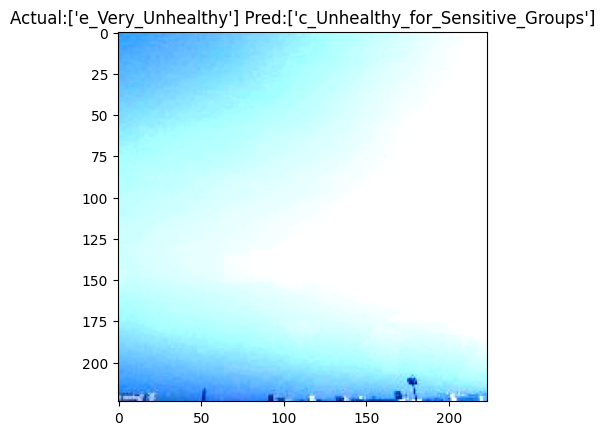

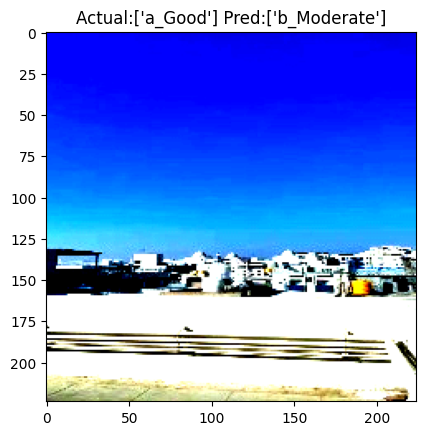

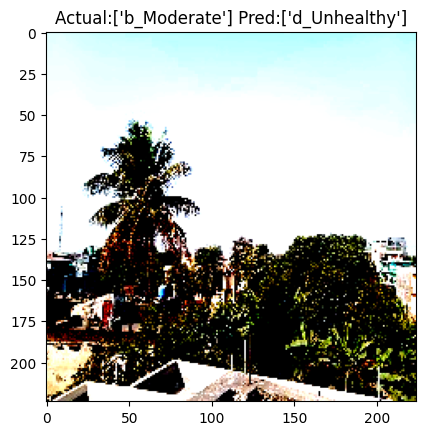

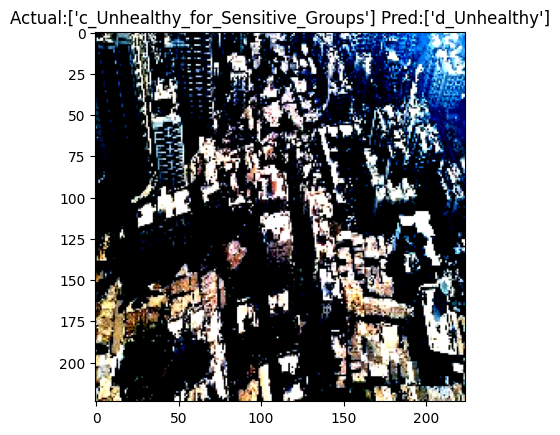

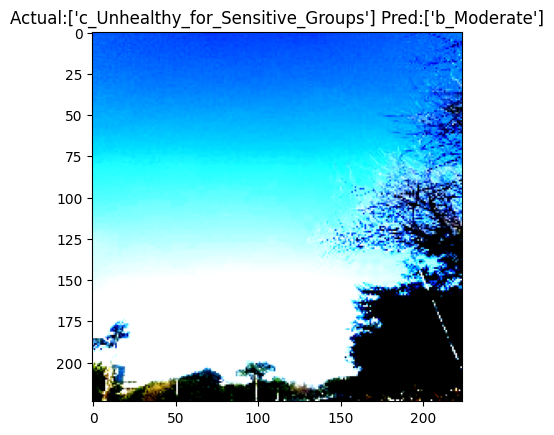

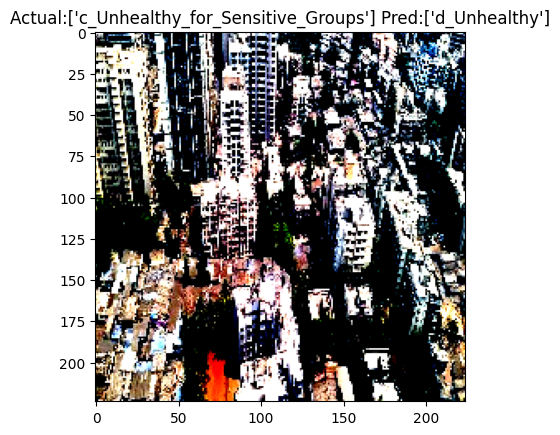

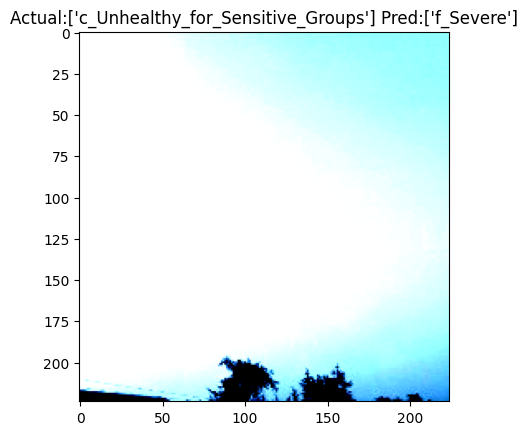

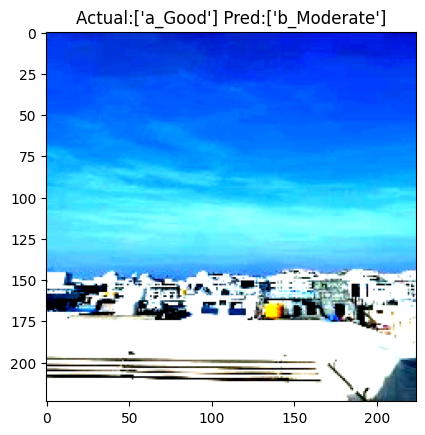

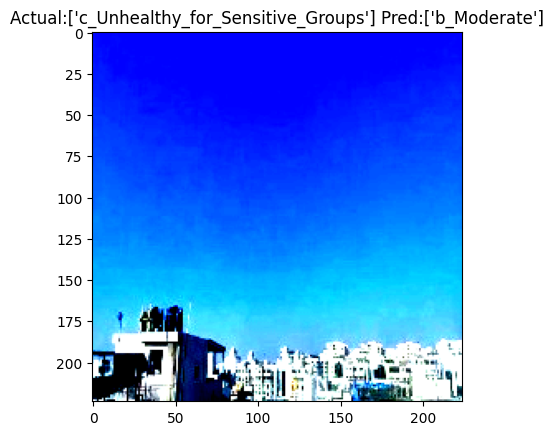

In [32]:
for ind in misclassified[:10]:
    img, label = test_dataset[ind]
    plt.imshow(img.permute(1,2,0))
    plt.title(f"Actual:{le.inverse_transform([y_true_res[ind]])} Pred:{le.inverse_transform([y_pred_res[ind]])}")
    plt.show()

## Possible reasons for misclassification:

Images may contain low visibility

Some classes have very similar visual patterns

Dataset imbalance

Poor lighting or noise in images

Background objects confusing the model